📥 Téléchargement de l'univers US (Secteurs + Refuges)...
✅ Données prêtes : 3324 jours de cotation.

🚀 Lancement du supercalculateur sur 1512 modèles...
   (Test en cours : Fréquences Quotidienne vs Hebdo vs Mensuelle)



/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_7615/1518566086.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_weights = final_weights.ffill().fillna(0)
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_7615/1518566086.py:57: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  rebalance_dates = prices.resample(rebalance_freq).last().index
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_7615/1518566086.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_we

,Mom_Window,Vol_Window,Top_N,Lev,Freq,CAGR,Max Drawdown,Sharpe,Frais,Config_Name
468,60,60,5,1.0,Mois,0.133077,-0.236562,0.906719,2.2%,Mom:60j|Vol:60j|Top:5|Lev:x1.0|Reb:Mois
300,60,30,5,1.0,Mois,0.131357,-0.227693,0.906452,2.3%,Mom:60j|Vol:30j|Top:5|Lev:x1.0|Reb:Mois
1182,252,30,2,1.0,Mois,0.165986,-0.293542,0.902668,2.3%,Mom:252j|Vol:30j|Top:2|Lev:x1.0|Reb:Mois
132,60,20,5,1.0,Mois,0.131050,-0.234474,0.899433,2.3%,Mom:60j|Vol:20j|Top:5|Lev:x1.0|Reb:Mois
1350,252,60,2,1.0,Mois,0.165383,-0.293659,0.898512,2.3%,Mom:252j|Vol:60j|Top:2|Lev:x1.0|Reb:Mois
1014,252,20,2,1.0,Mois,0.164526,-0.293250,0.896151,2.3%,Mom:252j|Vol:20j|Top:2|Lev:x1.0|Reb:Mois
1348,252,60,2,1.0,Mois,0.151774,-0.293768,0.863019,1.2%,Mom:252j|Vol:60j|Top:2|Lev:x1.0|Reb:Mois
1012,252,20,2,1.0,Mois,0.149922,-0.294701,0.856116,1.2%,Mom:252j|Vol:20j|Top:2|Lev:x1.0|Reb:Mois
1180,252,30,2,1.0,Mois,0.149665,-0.294229,0.852341,1.2%,Mom:252j|Vol:30j|Top:2|Lev:x1.0|Reb:Mois
1189,252,30,2,1.5,Mois,0.219254,-0.423091,0.838378,3.4%,Mom:252j|Vol:30j|Top:2|Lev:x1.5|Reb:Mois



🏆 LE MODÈLE GAGNANT EST : Mom:60j|Vol:60j|Top:5|Lev:x1.0|Reb:Mois


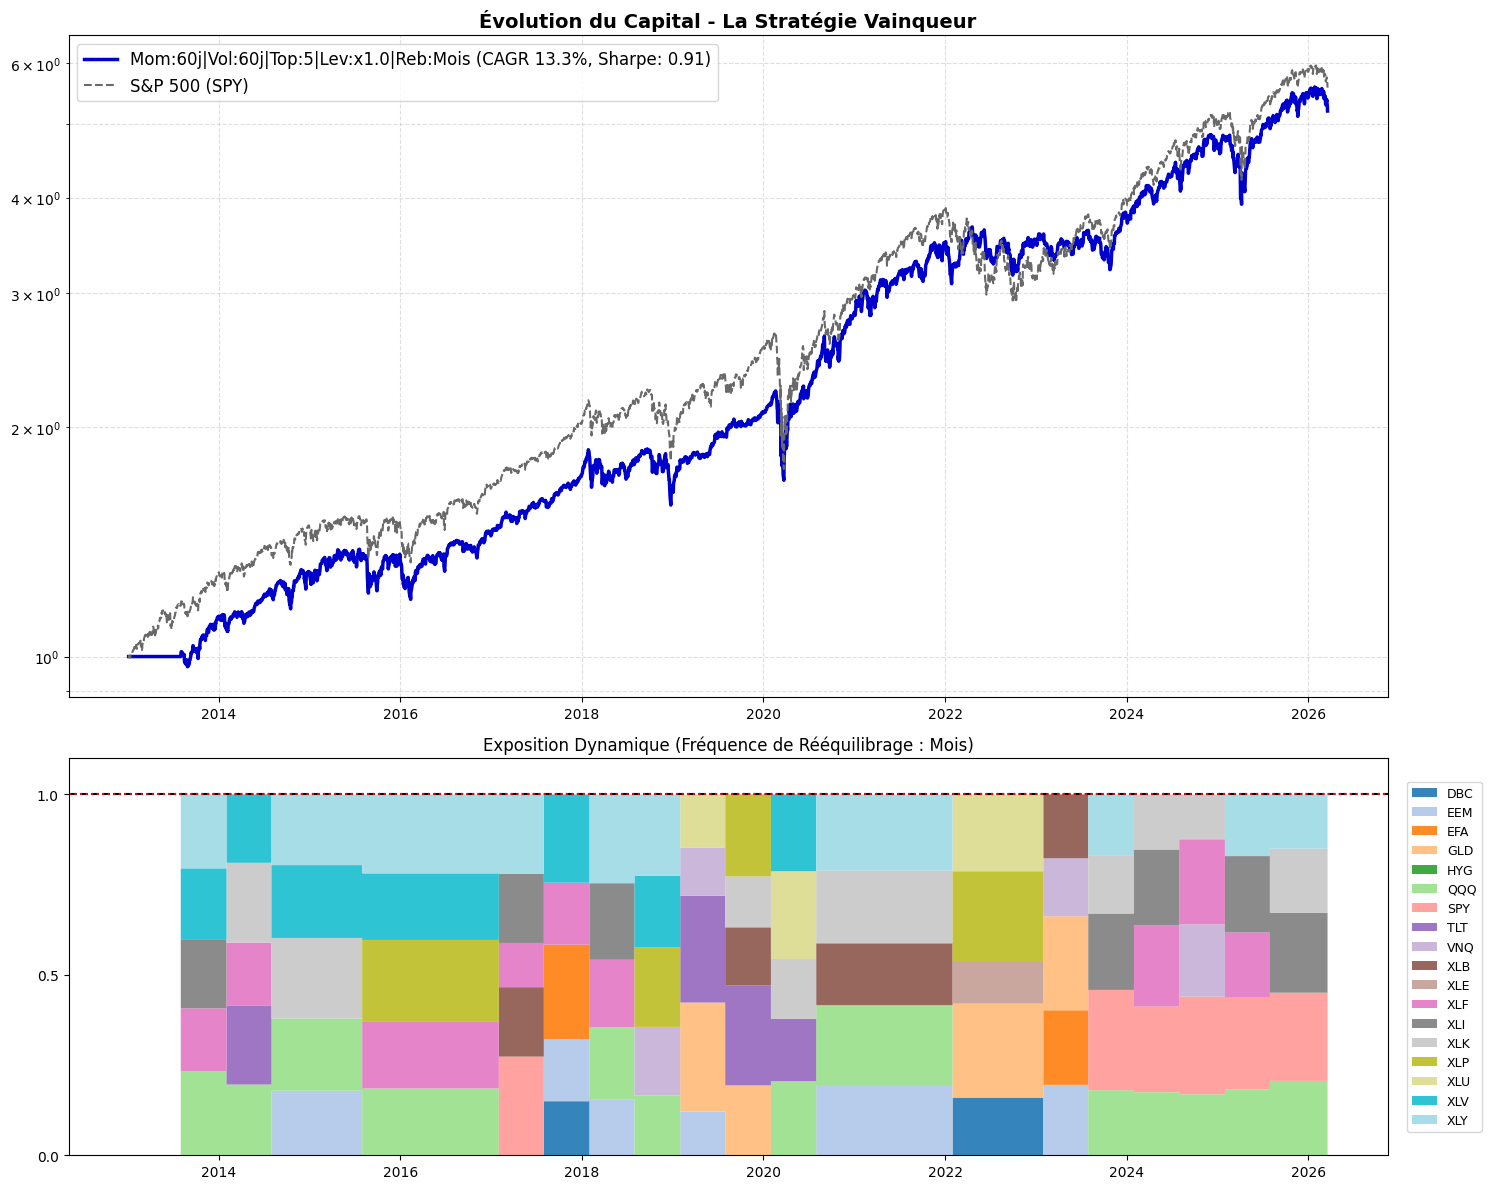

In [65]:
import pandas as pd
import numpy as np
import yfinance as yf
import itertools
import matplotlib.pyplot as plt

# ==========================================
# 1. TÉLÉCHARGEMENT DE L'UNIVERS US + MACRO
# ==========================================
def fetch_us_sector_data():
    print("📥 Téléchargement de l'univers US (Secteurs + Refuges)...")
    tickers = [
        'SPY', 'QQQ', 'EFA', 'EEM', 'VNQ', 'GLD', 'DBC', 'TLT', 'HYG',
        'XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB',
    ]
    data = yf.download(tickers, start='2013-01-01', end='2026-03-23', progress=False)['Close']
    df = data.ffill().dropna()
    print(f"✅ Données prêtes : {len(df)} jours de cotation.\n")
    return df

# ==========================================
# 2. MOTEUR GTAA (AVEC FRÉQUENCE VARIABLE)
# ==========================================
# ==========================================
# 2. MOTEUR GTAA (CORRECTION DE LA PÉRIODE DE CHAUFFE)
# ==========================================
def run_factor_gtaa_opt(prices, mom_window, vol_window, top_n, leverage, rebalance_freq, fee_rate=0.001, margin_rate=0.04):
    daily_returns = prices.pct_change()
    
    momentum = prices.pct_change(periods=mom_window)
    volatility = daily_returns.rolling(window=vol_window).std()
    
    positive_mom_mask = momentum > 0
    ranks = momentum.rank(axis=1, ascending=False)
    selected_mask = (ranks <= top_n) & positive_mom_mask
    
    inv_vol = 1.0 / volatility
    inv_vol_selected = inv_vol[selected_mask].fillna(0)
    
    total_inv_vol = inv_vol_selected.sum(axis=1)
    base_weights = inv_vol_selected.div(total_inv_vol, axis=0).fillna(0)
    
    target_weights = base_weights * leverage
    
    # Gestion de la Fréquence
    if rebalance_freq == 'D':
        final_weights = target_weights
    else:
        rebalance_dates = prices.resample(rebalance_freq).last().index
        final_weights = pd.DataFrame(index=prices.index, columns=prices.columns)
        
        valid_dates = rebalance_dates.intersection(target_weights.index)
        final_weights.loc[valid_dates] = target_weights.loc[valid_dates]
        final_weights = final_weights.ffill().fillna(0)
        
    weights_prev = final_weights.shift(1).fillna(0)
    
    weight_changes = weights_prev.diff().fillna(0).abs()
    total_traded = weight_changes.sum(axis=1)
    transaction_costs = total_traded * fee_rate
    
    total_weight = weights_prev.sum(axis=1)
    borrowed_weight = np.maximum(0, total_weight - 1.0)
    daily_margin_cost = borrowed_weight * (margin_rate / 252)
    
    portfolio_gross_return = (weights_prev * daily_returns).sum(axis=1)
    portfolio_net_return = portfolio_gross_return - transaction_costs - daily_margin_cost
    
    result = pd.DataFrame(index=prices.index)
    result['Net_Return'] = portfolio_net_return
    
    for col in prices.columns:
        result[f'W_{col}'] = weights_prev[col]
        
    # 🌟 LA CORRECTION EST ICI : ON COUPE LA PÉRIODE DE CHAUFFE
    warmup_days = max(mom_window, vol_window)
    # On ajoute un petit buffer (+20j) car avec le rééquilibrage mensuel, le 1er trade peut arriver le mois d'après
    result = result.iloc[warmup_days + 20:].copy() 
    
    # On recalcule le capital à partir de 1.0 au moment exact où l'algorithme est prêt
    result['Capital'] = (1 + result['Net_Return']).cumprod()
    
    if result.empty: return result, 0, 0, 0, 0
    
    final_cap = result['Capital'].iloc[-1]
    n_years = len(result) / 252
    cagr = (final_cap ** (1 / n_years)) - 1 if final_cap > 0 else -1.0
    max_dd = ((result['Capital'] - result['Capital'].cummax()) / result['Capital'].cummax()).min()
    sharpe = (result['Net_Return'].mean() / result['Net_Return'].std()) * np.sqrt(252) if result['Net_Return'].std() > 0 else 0
    
    # On recalcule les frais totaux sur la période amputée
    total_fees = transaction_costs.iloc[warmup_days + 20:].sum() * 100 
    
    return result, cagr, max_dd, sharpe, total_fees

# ==========================================
# 3. LE SUPERCALCULATEUR (GRID SEARCH 5D)
# ==========================================
df_global = fetch_us_sector_data()

# 🛠️ TA GRILLE DE PARAMÈTRES (5 Dimensions)
param_grid = {
    'mom_window': [60, 126, 252],        # 3, 6, 12 mois
    'vol_window': [20, 30, 60],              # Volatilité courte ou longue
    'top_n': [2, 3, 4, 5],               # (J'ai enlevé le 6 pour limiter le temps de calcul)
    'leverage': [1.0, 1.5, 2.0, 3.0, 4, 5],    # Levier 
    'rebalance_freq': ['D', 'W-FRI', 'BM', 'ME', 'Y', '3ME', '6ME'] # Quotidien, Hebdomadaire (Vendredi), Mensuel
}

keys, values = zip(*param_grid.items())
combinations = list(itertools.product(*values))

print(f"🚀 Lancement du supercalculateur sur {len(combinations)} modèles...")
print(f"   (Test en cours : Fréquences Quotidienne vs Hebdo vs Mensuelle)\n")

results_list = []
dfs_dict = {}

for mom_w, vol_w, top_n, lev, freq in combinations:
    res_df, cagr, max_dd, sharpe, total_fees = run_global_gtaa_opt(
        df_global, mom_window=mom_w, vol_window=vol_w, top_n=top_n, leverage=lev, rebalance_freq=freq, fee_rate=0.001
    )
    
    # Formatage propre du nom de la fréquence
    freq_name = "Jour" if freq == 'D' else "Hebdo" if freq == 'W-FRI' else "Mois"
    config_name = f"Mom:{mom_w}j|Vol:{vol_w}j|Top:{top_n}|Lev:x{lev}|Reb:{freq_name}"
    dfs_dict[config_name] = res_df
    
    results_list.append({
        "Mom_Window": mom_w, "Vol_Window": vol_w, "Top_N": top_n, "Lev": lev, "Freq": freq_name,
        "CAGR": cagr, "Max Drawdown": max_dd, "Sharpe": sharpe, 
        "Frais": f"{total_fees:.1f}%",
        "Config_Name": config_name
    })

best_strats = pd.DataFrame(results_list).sort_values(by='Sharpe', ascending=False)
display(best_strats.head(10))

# ==========================================
# 4. GRAPHIQUE DU CHAMPION NET DE FRAIS
# ==========================================
best_config = best_strats.iloc[0]
best_name = best_config['Config_Name']
best_df = dfs_dict[best_name]

print(f"\n🏆 LE MODÈLE GAGNANT EST : {best_name}")

bench_spy = (1 + df_global['SPY'].pct_change().fillna(0)).cumprod()
bench_spy = bench_spy.loc[bench_spy.index >= best_df.index[0]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [2.5, 1.5]})

ax1.plot(best_df.index, best_df['Capital'], color='mediumblue', linewidth=2.5, 
         label=f"{best_name} (CAGR {best_config['CAGR']*100:.1f}%, Sharpe: {best_config['Sharpe']:.2f})")
ax1.plot(bench_spy.index, bench_spy, color='dimgray', linewidth=1.5, linestyle='--', label="S&P 500 (SPY)")

ax1.set_yscale('log')
ax1.set_title(f"Évolution du Capital - La Stratégie Vainqueur", fontsize=14, fontweight='bold')
ax1.grid(True, which="both", ls="--", alpha=0.4)
ax1.legend(loc='upper left', fontsize=12)

weight_cols = [f'W_{col}' for col in df_global.columns]
colors = plt.cm.tab20(np.linspace(0, 1, len(weight_cols)))

ax2.stackplot(best_df.index, 
              [best_df[col] for col in weight_cols],
              labels=df_global.columns,
              colors=colors, alpha=0.9, step='pre')

ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5)
ax2.axhline(y=float(best_config['Lev']), color='red', linestyle=':', linewidth=1.5)

ax2.set_title(f"Exposition Dynamique (Fréquence de Rééquilibrage : {best_config['Freq']})", fontsize=12)
ax2.set_yticks(np.arange(0, float(best_config['Lev']) + 0.5, 0.5))
ax2.set_ylim(0, float(best_config['Lev']) + 0.1)

ax2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, ncol=1)

plt.tight_layout()
plt.show()